# Build the WGAST training-day manifest

For each city we want a list of **training-eligible days** for the WGAST
secondary model. A day `d0` is eligible iff:

1. **MODIS LST is clear over the AOI on `d0`** — this is the only input WGAST
   needs on the prediction day itself.
2. **There exists a past reference day `t0 < d0` on which Sentinel-2 *and*
   Landsat 8 *and* MODIS were all simultaneously clear** — this is the
   "reference snapshot" t0 that WGAST consumes as a bundle.
3. **The gap `d0 - t0` is at most `max_gap_days`** (default 30) — otherwise
   the reference scene is too stale to trust.

The output is a parquet file at `data/manifest_{city}.parquet` with one row
per `(d0, t0)` pair. Downstream feature builders read this file.


In [1]:
# --- Imports & configuration --------------------------------------------------
import sys, os
sys.path.append(os.path.abspath('..'))  # let us import the data_download package

import numpy as np
import pandas as pd
from bisect import bisect_left

from data_download.Sentinel2Processor import Sentinel2Processor
from data_download.Landsat8Processor  import Landsat8Processor
from data_download.MODISProcessor     import MODISProcessor

from cities import CITIES, EXPERIMENT

city      = "Rome"   # <-- the ONE switch; any key of EXPERIMENT
RANGE_IDX = 1            # which chunk of EXPERIMENT[city]["ranges"] to download
                         # (Rome/Cairo have two: run this notebook once per chunk)

roi = CITIES[city]["roi"]
start_date, end_date = EXPERIMENT[city]["ranges"][RANGE_IDX]
print(f"{city} [{EXPERIMENT[city]['split']}] chunk {RANGE_IDX}: {start_date} -> {end_date}")

pixel_threshold_d0 = 80  # % valid pixels for the MODIS target day (WGAST targets stay clean)
pixel_threshold_t0 = 60  # % valid pixels for t0 reference scenes — the same-day
                         # LS+S2+MODIS triple is the bottleneck (16-day vs 5-day
                         # orbit cycles), so accept hazier reference scenes
max_gap_days    = 50   # max staleness allowed for the t0 reference snapshot
S2_TOL_DAYS     = 2    # S2 reference scene may be up to this many days from the
                       # Landsat t0 day (±2-day bundle) — same-day LS+S2 passes
                       # are orbit-rare; the indices change slowly enough


Rome [val] chunk 1: 2022-08-01 -> 2022-09-30


In [2]:
# --- MODIS: needed at d0 (target) AND at t0 (reference) -----------------------
# MODIS LST, 1 km, daily revisit. The d0 candidates come from here.
# Filtered twice: strict (d0 targets must be clean) and relaxed (t0 pool).

modis = MODISProcessor(start_date=start_date, end_date=end_date, bounds=roi)
modis_coll = modis.get_MODIS_collection()

modis_f_d0   = modis.filter_disponible_images(modis_coll, pixel_threshold_d0)
modis_lst_d0 = modis.get_LST(modis_f_d0)
# MODIS timestamps come out as "YYYY-MM-DD HH:MM:SS" — strip the time-of-day.
dates_modis_d0 = np.array([t.split(" ")[0] for t in modis.get_formatted_times(modis_f_d0)])

modis_f_t0   = modis.filter_disponible_images(modis_coll, pixel_threshold_t0)
modis_lst_t0 = modis.get_LST(modis_f_t0)
dates_modis_t0 = np.array([t.split(" ")[0] for t in modis.get_formatted_times(modis_f_t0)])

print(f"MODIS clear days over AOI: d0@{pixel_threshold_d0}%: {len(dates_modis_d0)}   "
      f"t0@{pixel_threshold_t0}%: {len(dates_modis_t0)}")


MODIS clear days over AOI: d0@80%: 33   t0@60%: 41


In [3]:
# --- Landsat 8: needed at t0 only ---------------------------------------------
# Landsat 8 LST + 3 indices, 30 m, ~16-day revisit. t0-side -> relaxed threshold.

landsat = Landsat8Processor(start_date=start_date, end_date=end_date, bounds=roi)

landsat_coll          = landsat.get_Landsat_collection()
landsat_coll_filtered = landsat.filter_disponible_images(landsat_coll, pixel_threshold_t0)
landsat_lst_idx       = landsat.get_LST_index(landsat_coll_filtered)

# Landsat timestamps come out as "YYYY-MM-DDTHH:MM:SS" — split on the "T".
landsat_times = landsat.get_times(landsat_lst_idx)
dates_landsat = np.array([t.split("T")[0] for t in landsat_times])

print(f"Landsat 8 clear days over AOI: {len(dates_landsat)}")


Landsat 8 clear days over AOI: 3


In [4]:
# --- Sentinel-2: needed at t0 only --------------------------------------------
# Sentinel-2 indices (NDVI/NDWI/NDBI), 10 m, 5-day revisit. t0-side -> relaxed threshold.

sentinel = Sentinel2Processor(start_date=start_date, end_date=end_date, bounds=roi)

sentinel_coll          = sentinel.get_Sentinel2_collection()
sentinel_coll_filtered = sentinel.filter_disponible_images(sentinel_coll, pixel_threshold_t0)
sentinel_indices       = sentinel.get_index(sentinel_coll_filtered)

# Same "YYYY-MM-DDTHH:MM:SS" format as Landsat.
sentinel_times = sentinel.get_times(sentinel_indices)
dates_sentinel = np.array([t.split("T")[0] for t in sentinel_times])

print(f"Sentinel-2 clear days over AOI: {len(dates_sentinel)}")


Sentinel-2 clear days over AOI: 18


dem

In [5]:
import ee, geemap

# Ensure the output dir exists (geemap won't create it; first writer of the run).
os.makedirs(f"data/secondary/raw", exist_ok=True)

# Copernicus GLO-30: best free global DEM, 30 m resolution.
# Asset: "COPERNICUS/DEM/GLO30", band "DEM".
dem_path = f"data/secondary/raw/DEM_{city}.tif"
if os.path.exists(dem_path):
    print(f"[skip] DEM already on disk: {dem_path}")
else:
    dem = (ee.ImageCollection("COPERNICUS/DEM/GLO30")
            .filterBounds(modis.aoi)
            .select("DEM")
            .mosaic()
            .clip(modis.aoi))
    geemap.ee_export_image(
        dem,
        filename=dem_path,
        scale=30,                    # native DEM resolution
        region=modis.aoi,
        file_per_band=False,
    )

[skip] DEM already on disk: data/secondary/raw/DEM_Rome.tif


## Build the manifest

Two simple set operations + one loop:

1. **t0 pool** = `dates_sentinel ∩ dates_landsat ∩ dates_modis` (days where all
   three satellites are simultaneously clear).
2. For each `d0` in `dates_modis`, use `bisect_left` to find the most recent
   `t0 < d0` in the pool. Drop the row if no such t0 exists or if the gap is
   greater than `max_gap_days`.

Using `pd.Timestamp` for the date math — never subtract date *strings*.


In [6]:
# --- Build the (d0, t0) manifest ----------------------------------------------

# Step 1: t0 pool. The anchor is a day where Landsat AND MODIS are clear (the
# LST comes from these); the S2 reference scene may be up to S2_TOL_DAYS away
# (±2-day bundle) — indices change slowly, same-day LS+S2 passes are orbit-rare.
s2_ts = sorted(pd.Timestamp(str(d)) for d in set(dates_sentinel))
t0_pool = []  # (t0, s2_date) pairs
for d in sorted(set(dates_landsat) & set(dates_modis_t0)):
    t0_ts = pd.Timestamp(str(d))
    best = None
    for s in s2_ts:
        dd = abs((s - t0_ts).days)
        if dd <= S2_TOL_DAYS and (best is None or dd < abs((best - t0_ts).days)):
            best = s
    if best is not None:
        t0_pool.append((t0_ts, best))
print(f"t0 pool (LS+MODIS clear, S2 within ±{S2_TOL_DAYS}d): {len(t0_pool)} days")

t0_pool_ts = [t for t, _ in t0_pool]
s2_for_t0  = dict(t0_pool)
d0_candidates = sorted({pd.Timestamp(str(d)) for d in dates_modis_d0})

# Step 2: pair each d0 with the most recent valid t0.
rows = []
for d0 in d0_candidates:
    # bisect_left gives the insertion point for d0; the entry just BEFORE it is
    # the most recent t0 strictly less than d0.
    i = bisect_left(t0_pool_ts, d0) - 1
    if i < 0:
        continue                              # no past t0 exists yet
    t0  = t0_pool_ts[i]
    gap = (d0 - t0).days
    if gap > max_gap_days:
        continue                              # reference is too stale
    rows.append({"region": city, "d0": d0, "t0": t0,
                 "t0_s2": s2_for_t0[t0], "gap_days": gap})

manifest = pd.DataFrame(rows)
print(f"\nManifest rows: {len(manifest)}")

print(manifest.head())
if len(manifest):
    print("\nGap-days distribution:")
    print(manifest["gap_days"].describe())


t0 pool (LS+MODIS clear, S2 within ±2d): 2 days

Manifest rows: 28
  region         d0         t0      t0_s2  gap_days
0   Rome 2022-08-06 2022-08-05 2022-08-03         1
1   Rome 2022-08-07 2022-08-05 2022-08-03         2
2   Rome 2022-08-08 2022-08-05 2022-08-03         3
3   Rome 2022-08-10 2022-08-05 2022-08-03         5
4   Rome 2022-08-11 2022-08-05 2022-08-03         6

Gap-days distribution:
count    28.000000
mean     21.428571
std      15.476215
min       1.000000
25%       7.500000
50%      19.500000
75%      35.500000
max      47.000000
Name: gap_days, dtype: float64


In [7]:
# --- Save manifest (MERGE with any previous chunks) ----------------------------
# Rome/Cairo are downloaded in two disjoint chunks and a year-long city may be
# done in several sittings, so append + dedupe instead of overwriting.
manifest_path = f"data/secondary/manifest_{city}.parquet"
if os.path.exists(manifest_path):
    old = pd.read_parquet(manifest_path)
    if "t0_s2" not in old.columns:   # rows from the strict same-day era
        old["t0_s2"] = old["t0"]
    manifest = (pd.concat([old, manifest], ignore_index=True)
                  .drop_duplicates(subset=["d0"])
                  .sort_values("d0")
                  .reset_index(drop=True))
manifest.to_parquet(manifest_path, index=False)
print(f"Saved -> {manifest_path}  ({len(manifest)} rows total)")


Saved -> data/secondary/manifest_Rome.parquet  (28 rows total)


## (Optional) Export the rasters the manifest points at

Export only what the manifest actually uses:

- **MODIS LST at every `d0`** (the daily target-day input)
- **MODIS LST at every `t0`** (the reference-day MODIS input)
- **Landsat 8 LST+indices at every `t0`**
- **Sentinel-2 indices at every `t0`**

`filter_by_common_dates` keeps only images whose date is in a given list — same
helper used in `01_data_download.ipynb`. Note that `Sentinel2Processor` does not
define this method itself, so we borrow the MODIS processor's implementation
(it's a generic server-side date filter on an `ee.ImageCollection`).


In [8]:
# --- Export rasters (per-DATE resumable) ---------------------------------------
# Each export skips dates whose files are already on disk, so re-running the
# cell — or extending a city by another date chunk — only downloads what's
# missing. To force a redo of one date, delete that date's file(s).
#
# NOTE: MODIS is exported with crs="EPSG:4326". GEE's native MODIS export is in
# Sinusoidal projection, and the written GeoTIFF gets tagged with the WGS84
# ELLIPSOID instead of the MODIS authalic SPHERE (R=6371007.181 m). That bad tag
# places the raster ~18 km north of the Landsat/Sentinel AOI, so the downstream
# reproject in WGAST_Outputs.warp() finds no overlap and writes all-zeros ->
# WGAST then sees an empty coarse-LST input and emits the same raster every day.
# Forcing a clean CRS at export side-steps the mislabelled sinusoidal.
import re
import geemap

d0_dates = manifest["d0"].dt.strftime("%Y-%m-%d").unique()
t0_dates = manifest["t0"].dt.strftime("%Y-%m-%d").unique()
s2_dates = manifest["t0_s2"].dt.strftime("%Y-%m-%d").unique()  # ±2-day bundle


def dates_on_disk(out_dir):
    """Dates already exported, parsed from filenames: '20220813' (S2/Landsat)
    or '2022_08_18' (MODIS) forms both supported."""
    if not os.path.isdir(out_dir):
        return set()
    found = set()
    for f in os.listdir(out_dir):
        m = re.search(r"(\d{8})", f) or re.search(r"(\d{4})_(\d{2})_(\d{2})", f)
        if m:
            s = "".join(m.groups())
            found.add(f"{s[:4]}-{s[4:6]}-{s[6:8]}")
    return found


def export_missing(collection, dates, out_dir, scale, region, label, crs=None):
    """Export only the dates of `collection` not already in out_dir."""
    os.makedirs(out_dir, exist_ok=True)
    missing = sorted(set(dates) - dates_on_disk(out_dir))
    if not missing:
        print(f"[skip] {label}: all {len(set(dates))} dates already on disk")
        return
    print(f"[export] {label}: {len(missing)}/{len(set(dates))} dates -> {out_dir}")
    coll = modis.filter_by_common_dates(collection, missing)
    kwargs = dict(out_dir=out_dir, scale=scale, region=region)
    if crs is not None:
        kwargs["crs"] = crs
    geemap.ee_export_image_collection(coll, **kwargs)


# MODIS at d0 (strict threshold) and t0 (relaxed threshold)
export_missing(
    modis_lst_d0, d0_dates,
    f"data/secondary/raw/MODIS_d0_{city}",
    scale=1000, region=modis.aoi, label="MODIS@d0", crs="EPSG:4326",
)

export_missing(
    modis_lst_t0, t0_dates,
    f"data/secondary/raw/MODIS_t0_{city}",
    scale=1000, region=modis.aoi, label="MODIS@t0", crs="EPSG:4326",
)

# Landsat 8 at t0
export_missing(
    landsat_lst_idx, t0_dates,
    f"data/secondary/raw/Landsat8_t0_{city}",
    scale=30, region=landsat.aoi, label="Landsat8@t0",
)

# Sentinel-2 at the bundle dates (t0_s2, within ±2 days of t0)
export_missing(
    sentinel_indices, s2_dates,
    f"data/secondary/raw/Sentinel2_t0_{city}",
    scale=10, region=sentinel.aoi, label="Sentinel2@t0",
)

print("Done.")

[skip] MODIS@d0: all 28 dates already on disk
[skip] MODIS@t0: all 2 dates already on disk
[skip] Landsat8@t0: all 2 dates already on disk
[skip] Sentinel2@t0: all 2 dates already on disk
Done.


shape: (4, 408, 450) dtype: float64 range: -0.9798850417137146 58.07490026000005


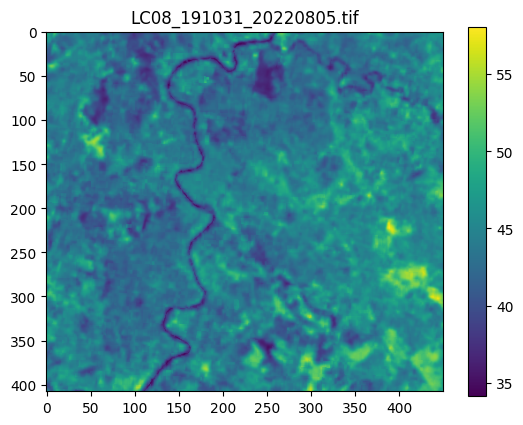

In [9]:
import rasterio, glob, matplotlib.pyplot as plt

# Preview the first exported Landsat t0 scene (filename varies with the date
# range, so glob instead of hard-coding a specific date).
paths = sorted(glob.glob(f"data/secondary/raw/Landsat8_t0_{city}/*.tif"))
assert paths, f"no Landsat t0 tifs found for {city} — run the export cell first"
path = paths[0]
with rasterio.open(path) as src:
    arr = src.read()
    print("shape:", arr.shape, "dtype:", arr.dtype, "range:", arr.min(), arr.max())
    plt.imshow(arr[0]); plt.colorbar(); plt.title(path.split("/")[-1])

Extend GGE 

In [10]:
import pandas as pd
from datetime import timedelta

window_days = 10

manifest = pd.read_parquet(f"data/secondary/manifest_{city}.parquet")

window_dates = set()

for d0 in manifest["d0"]:
    for k in range(1, window_days + 1):
        window_dates.add((d0 - pd.Timedelta(days=k)).strftime("%Y-%m-%d"))

window_dates = sorted(window_dates)
window_start = window_dates[0]
window_end = window_dates[-1]

sentinel_w = Sentinel2Processor(start_date=window_start,
                                end_date=window_end,
                                bounds=roi)

# window range, NOT the manifest range — otherwise scenes in the 10 days
# before the first d0 are silently missing (ROADMAP §10 C3)
landsat_w = Landsat8Processor(start_date=window_start,
                              end_date=window_end,
                              bounds=roi)


s2_coll = sentinel_w.get_Sentinel2_collection()
s2_indices = sentinel_w.get_index(s2_coll)

ls_coll = landsat_w.get_Landsat_collection()
ls_lst_idx = landsat_w.get_LST_index(ls_coll)

export_missing(
    s2_indices, window_dates,
    out_dir=f"data/secondary/raw/Sentinel2_window_{city}",
    scale=10, region=sentinel_w.aoi, label="S2@window",
)

export_missing(
    ls_lst_idx, window_dates,
    out_dir=f"data/secondary/raw/Landsat8_window_{city}",
    scale=30, region=landsat_w.aoi, label="Landsat@window",
)

import rasterio, glob
sample = sorted(glob.glob(f"data/secondary/raw/Sentinel2_window_{city}/*.tif"))[0]
with rasterio.open(sample) as src:
    print("S2 window sample:", sample.split("/")[-1])
    print("  shape:", (src.count, src.height, src.width), "  dtype:", src.dtypes[0])
    print("  bounds:", src.bounds)

[export] S2@window: 48/60 dates -> data/secondary/raw/Sentinel2_window_Rome
Total number of images: 0

[export] Landsat@window: 52/60 dates -> data/secondary/raw/Landsat8_window_Rome
Total number of images: 0

S2 window sample: 20220729T095559_20220729T095747_T32TQM.tif
  shape: (3, 1236, 1361)   dtype: float32
  bounds: BoundingBox(left=782930.0, bottom=4637310.0, right=796540.0, top=4649670.0)


open meteo

In [11]:

from get_Opene_Meteo import fetch_weather, fetch_target_weather
from cities import centroid

lat, lon = centroid(roi)

# Cover the earliest feature window: the first d0 reaches back 10 days before
# the manifest start (ROADMAP §10 C5).
wx_start = (manifest["d0"].min() - pd.Timedelta(days=window_days)).strftime("%Y-%m-%d")
wx_end   = manifest["d0"].max().strftime("%Y-%m-%d")

daily_df, hourly_df = fetch_weather(latitude=lat, longitude=lon,
                                    start_date=wx_start, end_date=wx_end)

daily_df.to_parquet(f"data/secondary/weather_{city}_daily.parquet")
hourly_df.to_parquet(f"data/secondary/weather_{city}_hourly.parquet")
print(f"weather {wx_start} -> {wx_end}: {len(daily_df)} daily rows, {len(hourly_df)} hourly rows")

# Target-day forecast block (ROADMAP §3.1): archived NWP forecasts for each d0,
# from the Historical Forecast API — the train-time stand-in for the live d+1
# forecast used at inference. Only the d0 dates need rows, but fetching the
# full range is one request either way.
d0_start = manifest["d0"].min().strftime("%Y-%m-%d")
target_df = fetch_target_weather(latitude=lat, longitude=lon,
                                 start_date=d0_start, end_date=wx_end)
target_df.to_parquet(f"data/secondary/weather_{city}_target_daily.parquet")
print(f"target-day forecast {d0_start} -> {wx_end}: {len(target_df)} daily rows")

weather 2022-07-27 -> 2022-09-25: 61 daily rows, 1464 hourly rows
target-day forecast 2022-08-06 -> 2022-09-25: 51 daily rows
